# 1.- Acceder a los datos y prepararlos para su analisis. 

## Importacion de las librerias necesarias.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt

## Importacion de los datos

In [2]:
visits_df = pd.read_csv('/datasets/visits_log_us.csv')
orders_df = pd.read_csv('/datasets/orders_log_us.csv')
costs_df = pd.read_csv('/datasets/costs_us.csv')

## Primer vistazo a los DataFrames

In [3]:
#DataFrame de visitas
print(visits_df.head())
print(visits_df.info())

    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage

In [4]:
#Convertiremos las columnas "End Ts" y "Start Ts" a fechas
visits_df['End Ts'] = pd.to_datetime(visits_df['End Ts'])
visits_df['Start Ts'] = pd.to_datetime(visits_df['Start Ts'])
print(visits_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  object        
 1   End Ts     359400 non-null  datetime64[ns]
 2   Source Id  359400 non-null  int64         
 3   Start Ts   359400 non-null  datetime64[ns]
 4   Uid        359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB
None


In [5]:
#Buscaremnos valores duplicados en el DataFrame visits_df
orders_df.duplicated().sum()


0

In [6]:
#Eliminamos los valores duplicados de orders_df
orders_df.drop_duplicates(inplace=True)

In [7]:
# DataFrame de ordenes
print(orders_df.head())
print(orders_df.info())

                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450
<class 'pandas.core.frame.DataFrame'>
Int64Index: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.5+ MB
None


In [8]:
#Se convierte la columna 'But Ts' a formato fecha
orders_df['Buy Ts'] = pd.to_datetime(orders_df['Buy Ts'])
print(orders_df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Buy Ts   50415 non-null  datetime64[ns]
 1   Revenue  50415 non-null  float64       
 2   Uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.5 MB
None


In [9]:
#Buscamos filas duplicadas en el DataFrame orders_df
orders_df[orders_df.duplicated()]

,Buy Ts,Revenue,Uid


In [10]:
#DataFrame de costos
print(costs_df.head())
print(costs_df.info())

   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06-03  36.53
3          1  2017-06-04  55.00
4          1  2017-06-05  57.08
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB
None


In [11]:
#Convertimos la columna 'dt' a formato de fecha
costs_df['dt'] = pd.to_datetime(costs_df['dt'])
print(costs_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB
None


In [12]:
#Buscando duplicados en el DataFrame costs_df
costs_df[costs_df.duplicated()]

,source_id,dt,costs


# 2.- Informes y calculo de métricas

## DataFrame visitas

### 2.1.1 ¿Cuántas personas lo usan cada día, semana y mes?

In [13]:
#Calculo de visitas por día
visitors_per_day = visits_df.groupby(visits_df['Start Ts'].dt.date)['Uid'].nunique().reset_index()
visitors_per_day.columns = ['date', 'visitors']
visitors_per_day.head()

,date,visitors
0,2017-06-01,605
1,2017-06-02,608
2,2017-06-03,445
3,2017-06-04,476
4,2017-06-05,820


In [14]:
#Promedio de personas que visitan por día
visitors_per_day_mean = '{:.2f}'.format(visitors_per_day['visitors'].mean())
print('Promedio de personas que hacen visitas diarias:', visitors_per_day_mean)

Promedio de personas que hacen visitas diarias: 907.99


In [15]:
#Calculo de visitas por semana
visitors_per_week = visits_df.groupby(visits_df['Start Ts'].dt.to_period('W'))['Uid'].nunique().reset_index()
visitors_per_week.columns = ['date_week', 'visitors']
visitors_per_week.head()


,date_week,visitors
0,2017-05-29/2017-06-04,2021
1,2017-06-05/2017-06-11,4129
2,2017-06-12/2017-06-18,2812
3,2017-06-19/2017-06-25,2878
4,2017-06-26/2017-07-02,3064


In [16]:
#Promedio de visitas por semana
visitors_per_week_mean = '{:.2f}'.format(visitors_per_week['visitors'].mean())
print('Promedio personas que visitan por semana:', visitors_per_week_mean)

Promedio personas que visitan por semana: 5716.25


In [17]:
#Promedio de visitas por mes
visitors_per_month = visits_df.groupby(visits_df['Start Ts'].dt.to_period('M'))['Uid'].nunique().reset_index()
visitors_per_month.columns = ['date_month','visitors']
visitors_per_month.head()

,date_month,visitors
0,2017-06,13259
1,2017-07,14183
2,2017-08,11631
3,2017-09,18975
4,2017-10,29692


In [18]:
#Promedio de visitas por mes
visitors_per_month_mean = '{:.2f}'.format(visitors_per_month['visitors'].mean())
print('Promedio personas que visitan por mes:', visitors_per_month_mean)

Promedio personas que visitan por mes: 23228.42


### 2.1.2 Cantidad de sesiones por día

In [19]:
visits_per_day = visits_df.groupby(visits_df['Start Ts'].dt.date)['Uid'].count().reset_index()
visits_per_day.columns = ['date', 'total_visits']
visits_per_day.head()

,date,total_visits
0,2017-06-01,664
1,2017-06-02,658
2,2017-06-03,477
3,2017-06-04,510
4,2017-06-05,893


In [20]:
#Promedio de visitas por día
visits_per_day_mean = '{:.2f}'.format(visits_per_day['total_visits'].mean())
print('Promedio de visitas diarias:', visits_per_day_mean)

Promedio de visitas diarias: 987.36


## 2.1.3 Duracion de cada sesion

In [21]:
visits_df['session_time'] = visits_df['End Ts'] - visits_df['Start Ts']
visits_df.head()

,Device,End Ts,Source Id,Start Ts,Uid,session_time
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,0 days 00:18:00
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,0 days 00:28:00
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,0 days 00:00:00
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,0 days 00:24:00
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,0 days 00:00:00


In [22]:
print('Tiempo promedio de la duracion de cada visita:', visits_df['session_time'].mean())

Tiempo promedio de la duracion de cada visita: 0 days 00:10:43.025687256


## 2.1.4 Frecuencia con la cual los usuarios vuelven a hacer una visita


In [23]:
#Obtenemos el mes de la primera visita para cada user
first_visit_user = visits_df.groupby('Uid')['Start Ts'].min().reset_index()
first_visit_user.columns = ['Uid', 'first_visit_date']
first_visit_user.head()

,Uid,first_visit_date
0,11863502262781,2018-03-01 17:27:00
1,49537067089222,2018-02-06 15:55:00
2,297729379853735,2017-06-07 18:47:00
3,313578113262317,2017-09-18 22:49:00
4,325320750514679,2017-09-30 14:29:00


In [24]:
#Añadimos esta columna del primer mes de visita al DataFrame visits_df
added_first_order_month = visits_df.merge(first_visit_user, on='Uid')
added_first_order_month.head()

,Device,End Ts,Source Id,Start Ts,Uid,session_time,first_visit_date
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,0 days 00:18:00,2017-12-20 17:20:00
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,0 days 00:28:00,2018-02-19 16:53:00
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,0 days 00:00:00,2017-07-01 01:54:00
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,0 days 00:24:00,2018-03-09 20:05:00
4,desktop,2018-03-09 20:33:00,4,2018-03-09 20:05:00,16174680259334210214,0 days 00:28:00,2018-03-09 20:05:00


In [25]:
#Damos formato a la columna "first_visit_date" para visualizarla en formato de año y mes
added_first_order_month['first_visit_date'] = added_first_order_month['first_visit_date'].dt.to_period('M')
added_first_order_month.head()


,Device,End Ts,Source Id,Start Ts,Uid,session_time,first_visit_date
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,0 days 00:18:00,2017-12
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,0 days 00:28:00,2018-02
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,0 days 00:00:00,2017-07
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,0 days 00:24:00,2018-03
4,desktop,2018-03-09 20:33:00,4,2018-03-09 20:05:00,16174680259334210214,0 days 00:28:00,2018-03


In [26]:
#Añadimos el año y mes de la visita de cada cliente en la columna "order_month"
added_first_order_month['order_month'] = added_first_order_month['Start Ts'].dt.to_period('M')
added_first_order_month.head()

,Device,End Ts,Source Id,Start Ts,Uid,session_time,first_visit_date,order_month
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,0 days 00:18:00,2017-12,2017-12
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,0 days 00:28:00,2018-02,2018-02
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,0 days 00:00:00,2017-07,2017-07
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,0 days 00:24:00,2018-03,2018-05
4,desktop,2018-03-09 20:33:00,4,2018-03-09 20:05:00,16174680259334210214,0 days 00:28:00,2018-03,2018-03


In [27]:
#Obtenemos la matriz de retencion entera de clientes que vuelven a visitar la pagina
absolute_visits = added_first_order_month.pivot_table(
    index = 'first_visit_date',
    columns= 'order_month',
    values = 'Uid',
    aggfunc = 'nunique'
)
absolute_visits

order_month,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05
first_visit_date,,,,,,,,,,,,
2017-06,13259.0,1043.0,713.0,814.0,909.0,947.0,809.0,766.0,694.0,674.0,539.0,596.0
2017-07,NaN,13140.0,737.0,674.0,738.0,765.0,633.0,596.0,601.0,510.0,376.0,361.0
2017-08,NaN,NaN,10181.0,783.0,640.0,639.0,510.0,448.0,370.0,402.0,284.0,265.0
2017-09,NaN,NaN,NaN,16704.0,1428.0,1156.0,847.0,658.0,632.0,599.0,404.0,381.0
2017-10,NaN,NaN,NaN,NaN,25977.0,2042.0,1357.0,1012.0,890.0,837.0,555.0,529.0
2017-11,NaN,NaN,NaN,NaN,NaN,27248.0,2133.0,1202.0,1054.0,919.0,638.0,594.0
2017-12,NaN,NaN,NaN,NaN,NaN,NaN,25268.0,1410.0,960.0,786.0,512.0,481.0
2018-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22624.0,1351.0,890.0,565.0,458.0
2018-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22197.0,1267.0,565.0,446.0


In [28]:
#Obtendremos la matriz de retencion porcentual
retention = absolute_visits.div(absolute_visits.apply(lambda row: row.dropna().iloc[0], axis=1), axis=0)
retention

order_month,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05
first_visit_date,,,,,,,,,,,,
2017-06,1.0,0.078664,0.053775,0.061392,0.068557,0.071423,0.061015,0.057772,0.052342,0.050833,0.040652,0.044951
2017-07,NaN,1.000000,0.056088,0.051294,0.056164,0.058219,0.048174,0.045358,0.045738,0.038813,0.028615,0.027473
2017-08,NaN,NaN,1.000000,0.076908,0.062862,0.062764,0.050093,0.044004,0.036342,0.039485,0.027895,0.026029
2017-09,NaN,NaN,NaN,1.000000,0.085489,0.069205,0.050706,0.039392,0.037835,0.035860,0.024186,0.022809
2017-10,NaN,NaN,NaN,NaN,1.000000,0.078608,0.052239,0.038958,0.034261,0.032221,0.021365,0.020364
2017-11,NaN,NaN,NaN,NaN,NaN,1.000000,0.078281,0.044113,0.038682,0.033727,0.023415,0.021800
2017-12,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.055802,0.037993,0.031107,0.020263,0.019036
2018-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.059715,0.039339,0.024973,0.020244
2018-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.057080,0.025454,0.020093


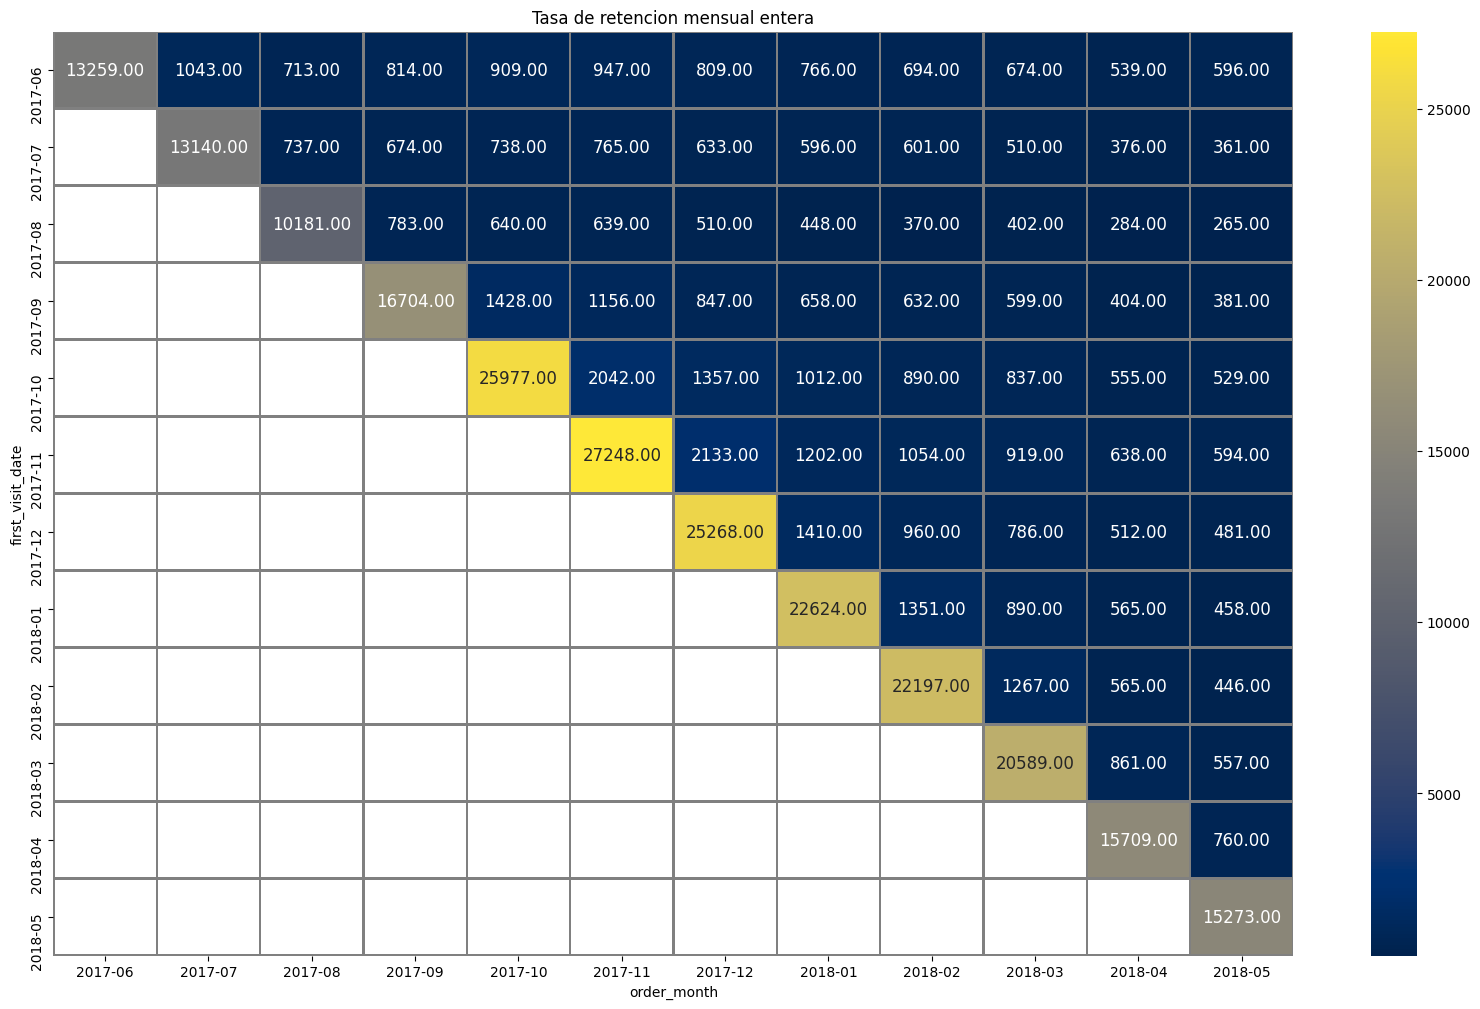

In [29]:
#Heatmap de la matriz de retencion entera

plt.figure(figsize= (20,12))
plt.title('Tasa de retencion mensual entera')

sns.heatmap(
    data= absolute_visits,
    annot= True,
    fmt='.2f',
    linewidths=1,
    linecolor='gray',
    annot_kws={'size':12},
    cbar=True,
    cmap='cividis'
)



plt.show()


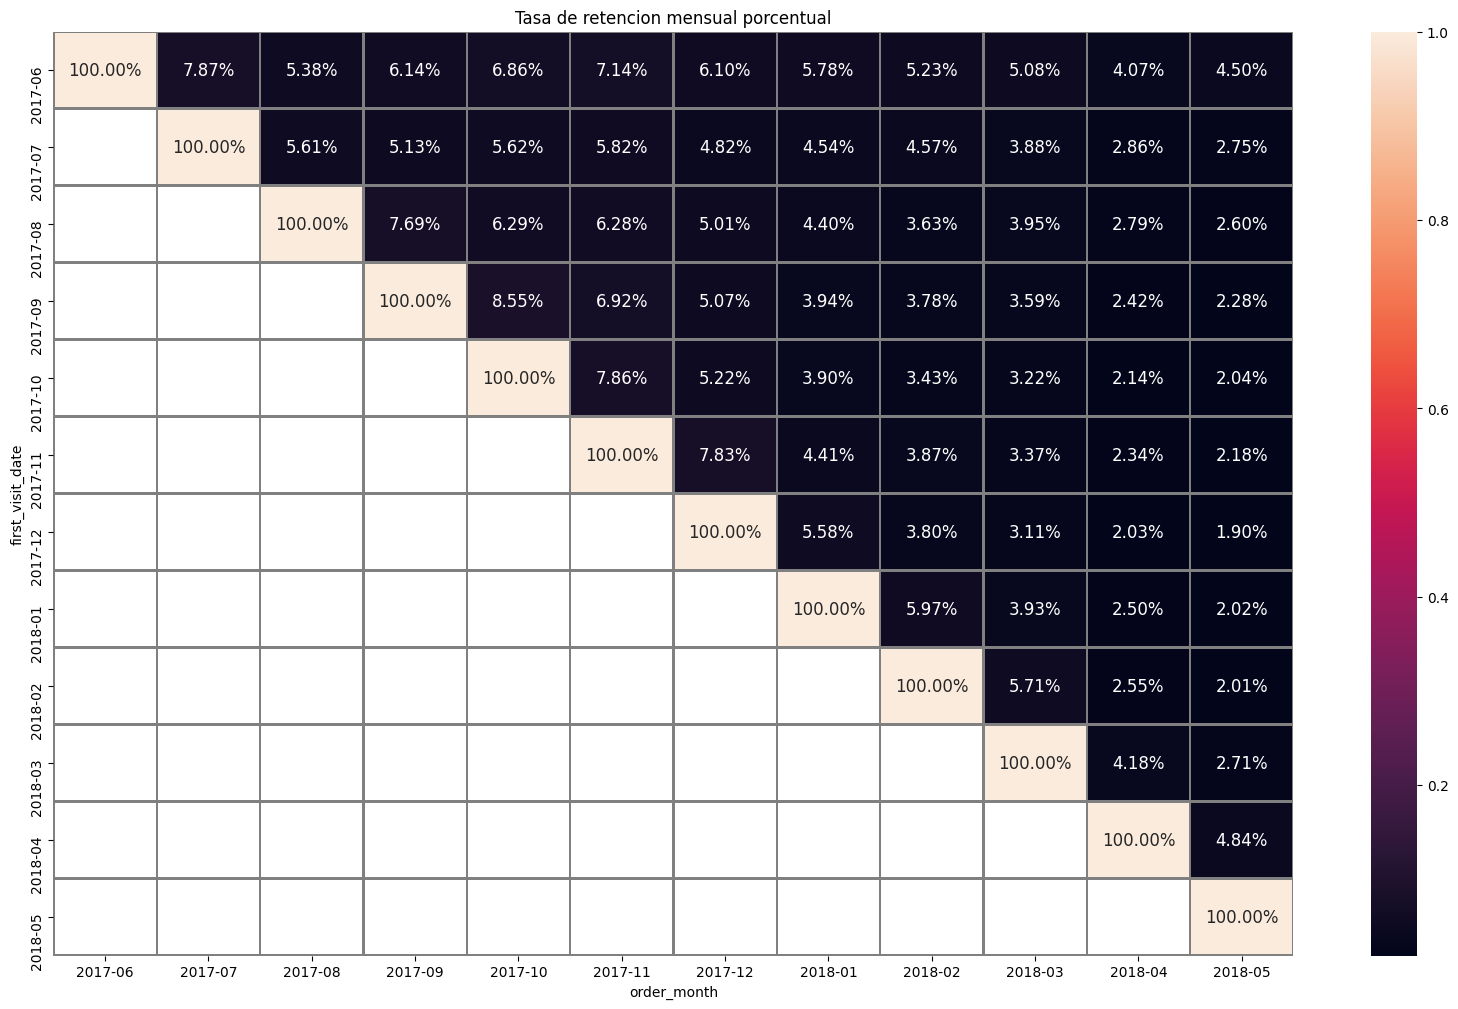

In [30]:
#Heatmap de la matriz de retencion porcentual
plt.figure(figsize= (20,12))
plt.title('Tasa de retencion mensual porcentual')

sns.heatmap(
    data= retention,
    annot= True,
    fmt='.2%',
    linewidths=1,
    linecolor='gray',
    annot_kws={'size':12},
    cbar=True,
    cmap='rocket'
)



plt.show()


In [31]:
'''
Podemos observar porcentajes relaticvamente bajos en la tasa de retencion mensual (menores al 10%, algunos incluso menores al 5%),
Aunque esto pudiera tambien a picos muy altos en la captacion de nuevos usuarios.
'''

'\nPodemos observar porcentajes relaticvamente bajos en la tasa de retencion mensual (menores al 10%, algunos incluso menores al 5%),\nAunque esto pudiera tambien a picos muy altos en la captacion de nuevos usuarios.\n'

# 2.2 Analisis de ventas

## 2.2.1 ¿Cuando comienza la gente a comprar?

In [32]:
#Obtendremos la fecha de la primera visita y la fecha de la primera compra de cada usuario
#DF con la fecha de la primera visita por usuario
first_visit_user.head()

,Uid,first_visit_date
0,11863502262781,2018-03-01 17:27:00
1,49537067089222,2018-02-06 15:55:00
2,297729379853735,2017-06-07 18:47:00
3,313578113262317,2017-09-18 22:49:00
4,325320750514679,2017-09-30 14:29:00


In [33]:
orders_df.head()

,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [34]:
#Primera compra de cada usuario
first_order_month = orders_df.groupby('Uid')['Buy Ts'].min()
first_order_month.rename('first_order_month')

Uid
313578113262317        2018-01-03 21:51:00
1575281904278712       2017-06-03 10:13:00
2429014661409475       2017-10-11 18:33:00
2464366381792757       2018-01-28 15:54:00
2551852515556206       2017-11-24 10:14:00
                               ...        
18445147675727495770   2017-11-24 09:03:00
18445407535914413204   2017-09-22 23:55:00
18445601152732270159   2018-03-26 22:54:00
18446156210226471712   2018-02-18 19:34:00
18446167067214817906   2017-10-17 10:16:00
Name: first_order_month, Length: 36523, dtype: datetime64[ns]

In [35]:
#Unimos los DF
convertion = first_visit_user.merge(first_order_month, on='Uid')
convertion.head()

,Uid,first_visit_date,Buy Ts
0,313578113262317,2017-09-18 22:49:00,2018-01-03 21:51:00
1,1575281904278712,2017-06-03 10:13:00,2017-06-03 10:13:00
2,2429014661409475,2017-10-11 17:14:00,2017-10-11 18:33:00
3,2464366381792757,2018-01-27 20:10:00,2018-01-28 15:54:00
4,2551852515556206,2017-11-24 10:14:00,2017-11-24 10:14:00


In [36]:
#Cambiamos los nombres de las columans
convertion.columns = ['Uid', 'first_visit', 'first_order']
convertion.head()

,Uid,first_visit,first_order
0,313578113262317,2017-09-18 22:49:00,2018-01-03 21:51:00
1,1575281904278712,2017-06-03 10:13:00,2017-06-03 10:13:00
2,2429014661409475,2017-10-11 17:14:00,2017-10-11 18:33:00
3,2464366381792757,2018-01-27 20:10:00,2018-01-28 15:54:00
4,2551852515556206,2017-11-24 10:14:00,2017-11-24 10:14:00


In [37]:
#Damos formato de AÑO, MES Y DIA a las columnas con fechas
convertion['first_visit'] = convertion['first_visit'].dt.date
convertion['first_order'] = convertion['first_order'].dt.date
convertion.head()

,Uid,first_visit,first_order
0,313578113262317,2017-09-18,2018-01-03
1,1575281904278712,2017-06-03,2017-06-03
2,2429014661409475,2017-10-11,2017-10-11
3,2464366381792757,2018-01-27,2018-01-28
4,2551852515556206,2017-11-24,2017-11-24


In [38]:
#Nos aseguramos de que todas las ordenes se hayan efectuado el mismo dia, o dias despues de la primera visita
convertion.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 36523 entries, 0 to 36522
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Uid          36523 non-null  uint64
 1   first_visit  36523 non-null  object
 2   first_order  36523 non-null  object
dtypes: object(2), uint64(1)
memory usage: 1.1+ MB


In [39]:
okay_orders = convertion.query("first_visit == first_order or first_visit <= first_order")
okay_orders.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 36523 entries, 0 to 36522
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Uid          36523 non-null  uint64
 1   first_visit  36523 non-null  object
 2   first_order  36523 non-null  object
dtypes: object(2), uint64(1)
memory usage: 1.1+ MB


In [40]:
#Vemos que no tenemos problemas con las fechas, podemos continuar con el analisis


In [41]:
#Crearemos una columna con la diferencia de dias entre la primer visita y la primer orden
convertion['days_to_first_order'] = convertion['first_order'] - convertion['first_visit']
convertion.head()

,Uid,first_visit,first_order,days_to_first_order
0,313578113262317,2017-09-18,2018-01-03,107 days
1,1575281904278712,2017-06-03,2017-06-03,0 days
2,2429014661409475,2017-10-11,2017-10-11,0 days
3,2464366381792757,2018-01-27,2018-01-28,1 days
4,2551852515556206,2017-11-24,2017-11-24,0 days


In [42]:
#Listado del tiempo que tardan los clientes en realizar un pedido.
convertion.loc[convertion['days_to_first_order'] > '30 days', 'category'] = 'Mas de un mes'
convertion.loc[convertion['days_to_first_order'] <=  '30 days', 'category'] = 'Hasta un mes'
convertion.loc[convertion['days_to_first_order'] <=  '7 days', 'category'] = 'Hasta una semana'
convertion.loc[convertion['days_to_first_order'] == '0 days', 'category'] = '0 días'

convertion.head(20)

,Uid,first_visit,first_order,days_to_first_order,category
0,313578113262317,2017-09-18,2018-01-03,107 days,Mas de un mes
1,1575281904278712,2017-06-03,2017-06-03,0 days,0 días
2,2429014661409475,2017-10-11,2017-10-11,0 days,0 días
3,2464366381792757,2018-01-27,2018-01-28,1 days,Hasta una semana
4,2551852515556206,2017-11-24,2017-11-24,0 days,0 días
5,3077748354309989,2018-03-03,2018-03-03,0 days,0 días
6,3605148382144603,2017-08-15,2017-09-21,37 days,Mas de un mes
7,3753586865891862,2018-03-03,2018-03-03,0 days,0 días
8,4808417689019433,2018-01-09,2018-01-09,0 days,0 días
9,4992223027560440,2018-04-04,2018-04-04,0 days,0 días


In [43]:
#Listado del tiempo que tardan los clientes en realizar un pedido.
category_convertion = convertion.groupby('category')['Uid'].count().reset_index()
category_convertion.columns = ['convertion', 'qty']
category_convertion = category_convertion.sort_values(by='qty', ascending=False)
category_convertion.head()

,convertion,qty
0,0 días,25039
3,Mas de un mes,4934
2,Hasta una semana,4297
1,Hasta un mes,2253


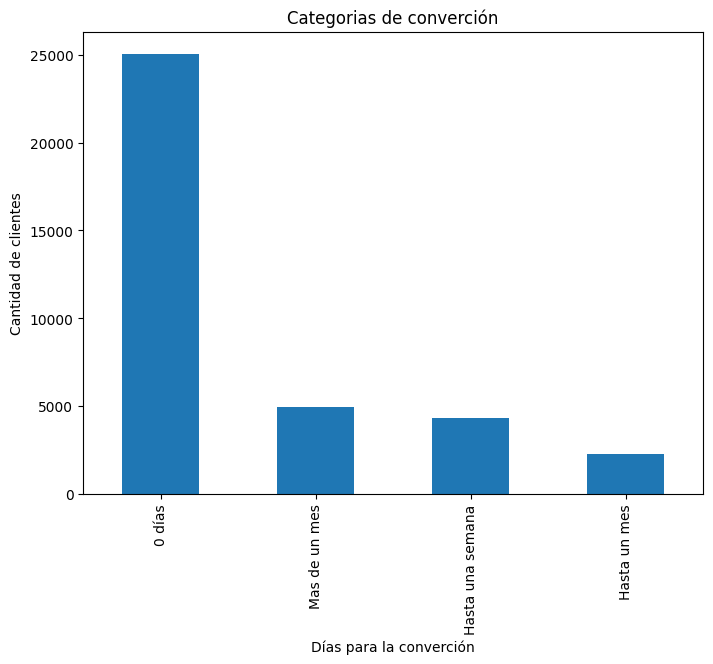

In [44]:
category_convertion.plot(
    kind='bar',
    title='Categorias de converción',
    x='convertion',
    y='qty',
    xlabel = 'Días para la converción',
    ylabel='Cantidad de clientes',
    figsize=(8,6),
    legend=False
)

plt.show()

In [45]:
'''
Podemos observar que en gran medida, la mayoria de los clientes hacen su primer compra en el día 0 despues de su primera visita.
'''

'\nPodemos observar que en gran medida, la mayoria de los clientes hacen su primer compra en el día 0 despues de su primera visita.\n'

### 2.2.1 ¿Cuantos pedidos hacen durante un periodo de tiempo dado?

In [46]:
orders_df['Buy Ts'] = pd.to_datetime(orders_df['Buy Ts']).dt.strftime('%Y-%m-%d')
orders_df['Buy Ts'] = pd.to_datetime(orders_df['Buy Ts'])

In [47]:
#Calcularemos el volumen de pedidos a partir de la convercion por periodo mensual. 
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Buy Ts   50415 non-null  datetime64[ns]
 1   Revenue  50415 non-null  float64       
 2   Uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.5 MB


In [48]:
#Obtenemos la primera fecha de compra de cada usuario
first_purchase = orders_df.groupby('Uid')['Buy Ts'].min()
first_purchase.name = 'first_purchase_date'
orders_cohorts = orders_df.merge(first_purchase, on='Uid')
orders_cohorts.head()

,Buy Ts,Revenue,Uid,first_purchase_date
0,2017-06-01,17.00,10329302124590727494,2017-06-01
1,2017-06-01,0.55,11627257723692907447,2017-06-01
2,2017-06-01,0.37,17903680561304213844,2017-06-01
3,2017-06-01,0.55,16109239769442553005,2017-06-01
4,2017-06-01,0.37,14200605875248379450,2017-06-01


In [49]:
#Añadimos el mes de cada uno de los pedidos realizados por los usuarios
orders_cohorts['purchase_month'] = pd.to_datetime(orders_cohorts['Buy Ts']).dt.to_period('M')
orders_cohorts['first_purchase_month'] = pd.to_datetime(orders_cohorts['first_purchase_date']).dt.to_period('M')
orders_cohorts.head()

,Buy Ts,Revenue,Uid,first_purchase_date,purchase_month,first_purchase_month
0,2017-06-01,17.00,10329302124590727494,2017-06-01,2017-06,2017-06
1,2017-06-01,0.55,11627257723692907447,2017-06-01,2017-06,2017-06
2,2017-06-01,0.37,17903680561304213844,2017-06-01,2017-06,2017-06
3,2017-06-01,0.55,16109239769442553005,2017-06-01,2017-06,2017-06
4,2017-06-01,0.37,14200605875248379450,2017-06-01,2017-06,2017-06


In [50]:
#Calculamos el tiempo transcurrido entre la primera compra y la fecha actual
orders_cohorts['cohort_lifetime'] = (orders_cohorts['Buy Ts'] - orders_cohorts['first_purchase_date']) / np.timedelta64(1, 'M')
orders_cohorts['cohort_lifetime'] = orders_cohorts['cohort_lifetime'].round().astype(int)
orders_cohorts.head()


,Buy Ts,Revenue,Uid,first_purchase_date,purchase_month,first_purchase_month,cohort_lifetime
0,2017-06-01,17.00,10329302124590727494,2017-06-01,2017-06,2017-06,0
1,2017-06-01,0.55,11627257723692907447,2017-06-01,2017-06,2017-06,0
2,2017-06-01,0.37,17903680561304213844,2017-06-01,2017-06,2017-06,0
3,2017-06-01,0.55,16109239769442553005,2017-06-01,2017-06,2017-06,0
4,2017-06-01,0.37,14200605875248379450,2017-06-01,2017-06,2017-06,0


In [51]:
orders_matrix = orders_cohorts.pivot_table(
    index='first_purchase_month',
    columns='cohort_lifetime',
    values='Buy Ts',
    aggfunc = 'count'
)
orders_matrix

cohort_lifetime,0,1,2,3,4,5,6,7,8,9,10,11,12
first_purchase_month,,,,,,,,,,,,,
2017-06,2356.0,146.0,154.0,234.0,278.0,204.0,275.0,198.0,211.0,176.0,108.0,65.0,33.0
2017-07,2190.0,92.0,114.0,104.0,71.0,68.0,76.0,60.0,51.0,27.0,44.0,13.0,NaN
2017-08,1562.0,98.0,99.0,87.0,66.0,61.0,70.0,59.0,52.0,34.0,NaN,NaN,NaN
2017-09,2962.0,193.0,167.0,146.0,79.0,114.0,93.0,61.0,54.0,9.0,NaN,NaN,NaN
2017-10,4983.0,273.0,184.0,127.0,119.0,99.0,89.0,95.0,36.0,NaN,NaN,NaN,NaN
2017-11,4954.0,256.0,221.0,179.0,129.0,63.0,78.0,20.0,NaN,NaN,NaN,NaN,NaN
2017-12,5065.0,239.0,217.0,178.0,80.0,99.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN
2018-01,3808.0,210.0,150.0,74.0,59.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02,4103.0,221.0,83.0,57.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


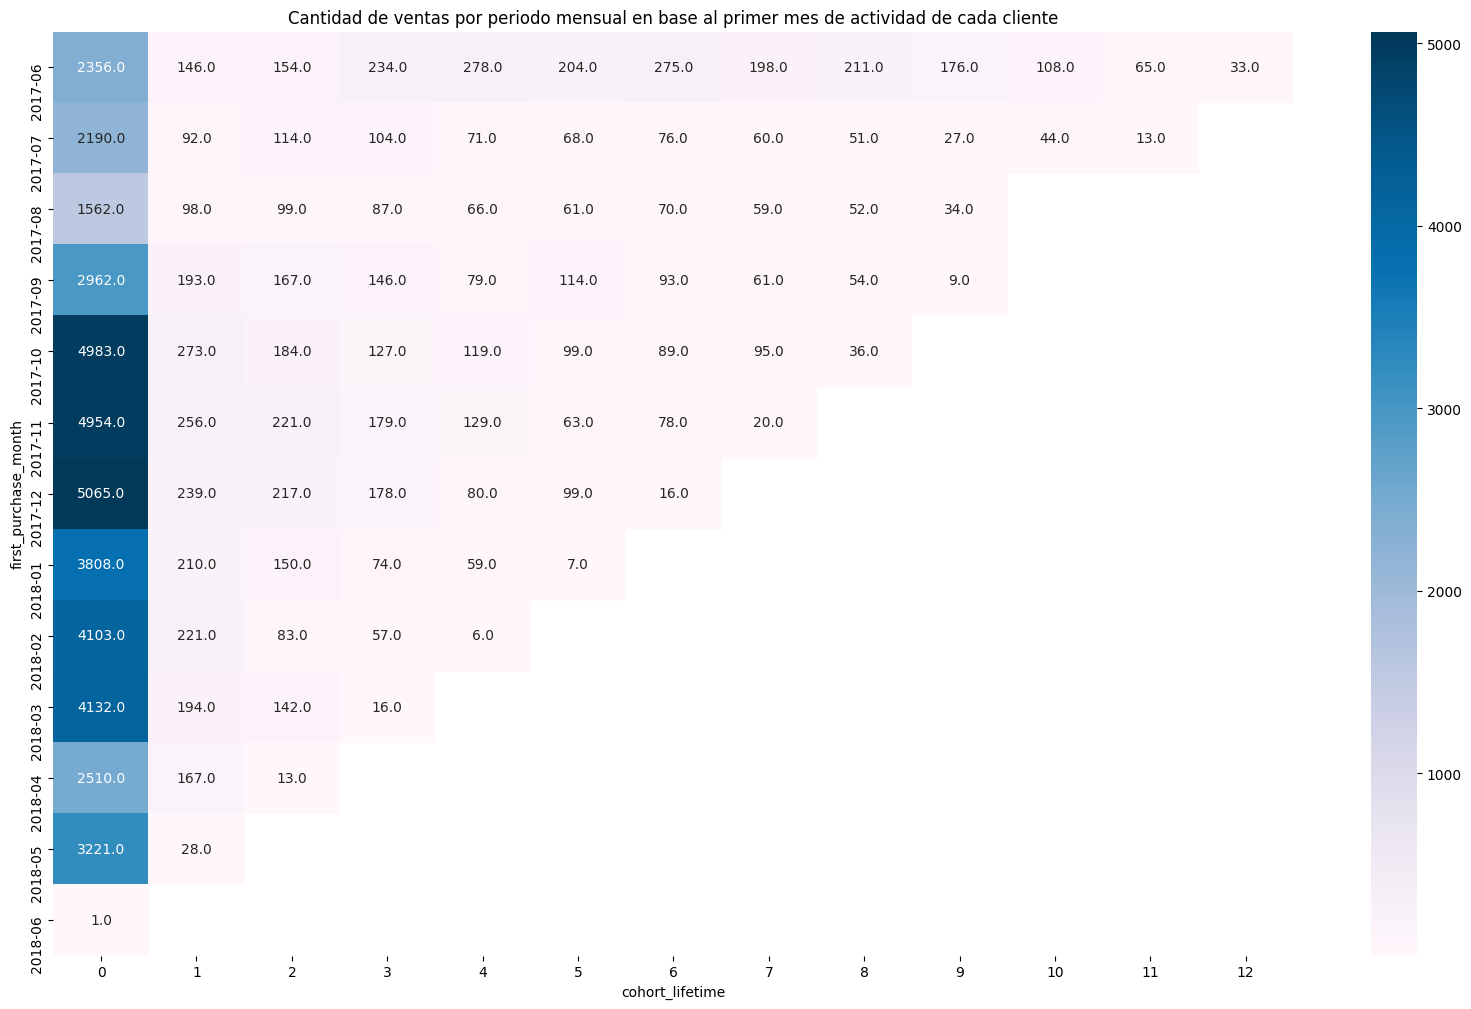

In [52]:

plt.figure(figsize = (20,12))
plt.title('Cantidad de ventas por periodo mensual en base al primer mes de actividad de cada cliente')

sns.heatmap(
    data= orders_matrix,
    annot=True,
    fmt='',
    linecolor='black',
    annot_kws={'size':10},
    cbar=True,
    cmap='PuBu'
)

plt.show()


### 2.2.3 ¿Cuál es el tamaño promedio de compra?

In [53]:
#Obtendremos el promedio del costo de la compra de manera mensual y por cohorte

purchase_mean = orders_cohorts.pivot_table(
    index='first_purchase_month',
    columns='cohort_lifetime',
    values='Revenue',
    aggfunc = 'mean'
)
purchase_mean


cohort_lifetime,0,1,2,3,4,5,6,7,8,9,10,11,12
first_purchase_month,,,,,,,,,,,,,
2017-06,4.085306,5.335685,5.059026,7.388675,7.963094,7.095245,6.568364,5.643535,6.927393,7.311534,10.711667,6.866000,5.548788
2017-07,5.293269,6.757391,10.031930,6.675865,4.974225,3.436618,3.238816,5.038500,6.766471,9.978148,4.755455,8.999231,NaN
2017-08,4.669590,7.490714,6.352828,7.697241,6.865758,6.324426,6.086857,6.817288,7.873462,5.971471,NaN,NaN,NaN
2017-09,5.014213,13.022332,15.437485,62.056370,19.648101,16.614123,8.990860,14.486066,6.856852,15.148889,NaN,NaN,NaN
2017-10,4.406753,7.327802,5.319293,4.948740,5.953697,4.438182,3.844270,5.029579,1.918056,NaN,NaN,NaN,NaN
2017-11,4.314499,5.057500,4.923529,5.732737,4.835039,4.046032,4.202436,5.478500,NaN,NaN,NaN,NaN,NaN
2017-12,4.087117,4.802887,18.647972,26.528652,16.767125,14.850606,3.519375,NaN,NaN,NaN,NaN,NaN,NaN
2018-01,3.676113,5.035190,7.112733,4.697703,2.965424,2.514286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02,3.695747,4.791267,3.277590,4.105263,3.656667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


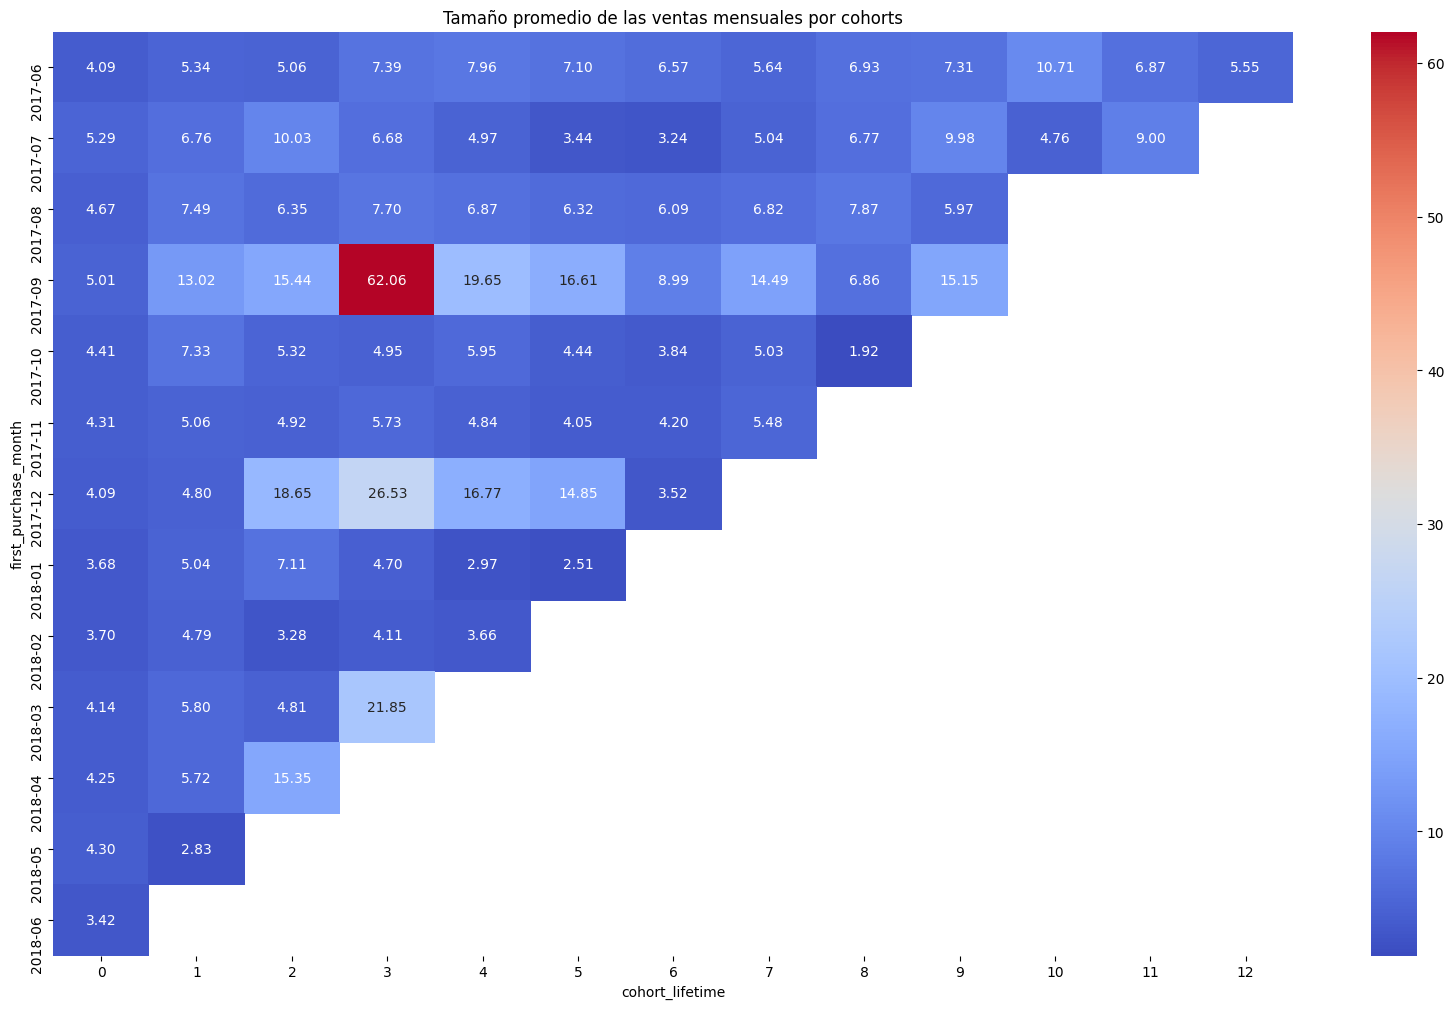

In [54]:

plt.figure(figsize = (20,12))
plt.title('Tamaño promedio de las ventas mensuales por cohorts')

sns.heatmap(
    data= purchase_mean,
    annot=True,
    fmt='.2f',
    linecolor='black',
    annot_kws={'size':10},
    cbar=True,
    cmap="coolwarm"
)

plt.show()



In [55]:
ltv = orders_cohorts.pivot_table(
    index = 'first_purchase_month',
    columns = 'cohort_lifetime',
    values = 'Revenue',
    aggfunc= 'sum'
)
ltv

cohort_lifetime,0,1,2,3,4,5,6,7,8,9,10,11,12
first_purchase_month,,,,,,,,,,,,,
2017-06,9624.98,779.01,779.09,1728.95,2213.74,1447.43,1806.30,1117.42,1461.68,1286.83,1156.86,446.29,183.11
2017-07,11592.26,621.68,1143.64,694.29,353.17,233.69,246.15,302.31,345.09,269.41,209.24,116.99,NaN
2017-08,7293.90,734.09,628.93,669.66,453.14,385.79,426.08,402.22,409.42,203.03,NaN,NaN,NaN
2017-09,14852.10,2513.31,2578.06,9060.23,1552.20,1894.01,836.15,883.65,370.27,136.34,NaN,NaN,NaN
2017-10,21958.85,2000.49,978.75,628.49,708.49,439.38,342.14,477.81,69.05,NaN,NaN,NaN,NaN
2017-11,21374.03,1294.72,1088.10,1026.16,623.72,254.90,327.79,109.57,NaN,NaN,NaN,NaN,NaN
2017-12,20701.25,1147.89,4046.61,4722.10,1341.37,1470.21,56.31,NaN,NaN,NaN,NaN,NaN,NaN
2018-01,13998.64,1057.39,1066.91,347.63,174.96,17.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02,15163.65,1058.87,272.04,234.00,21.94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


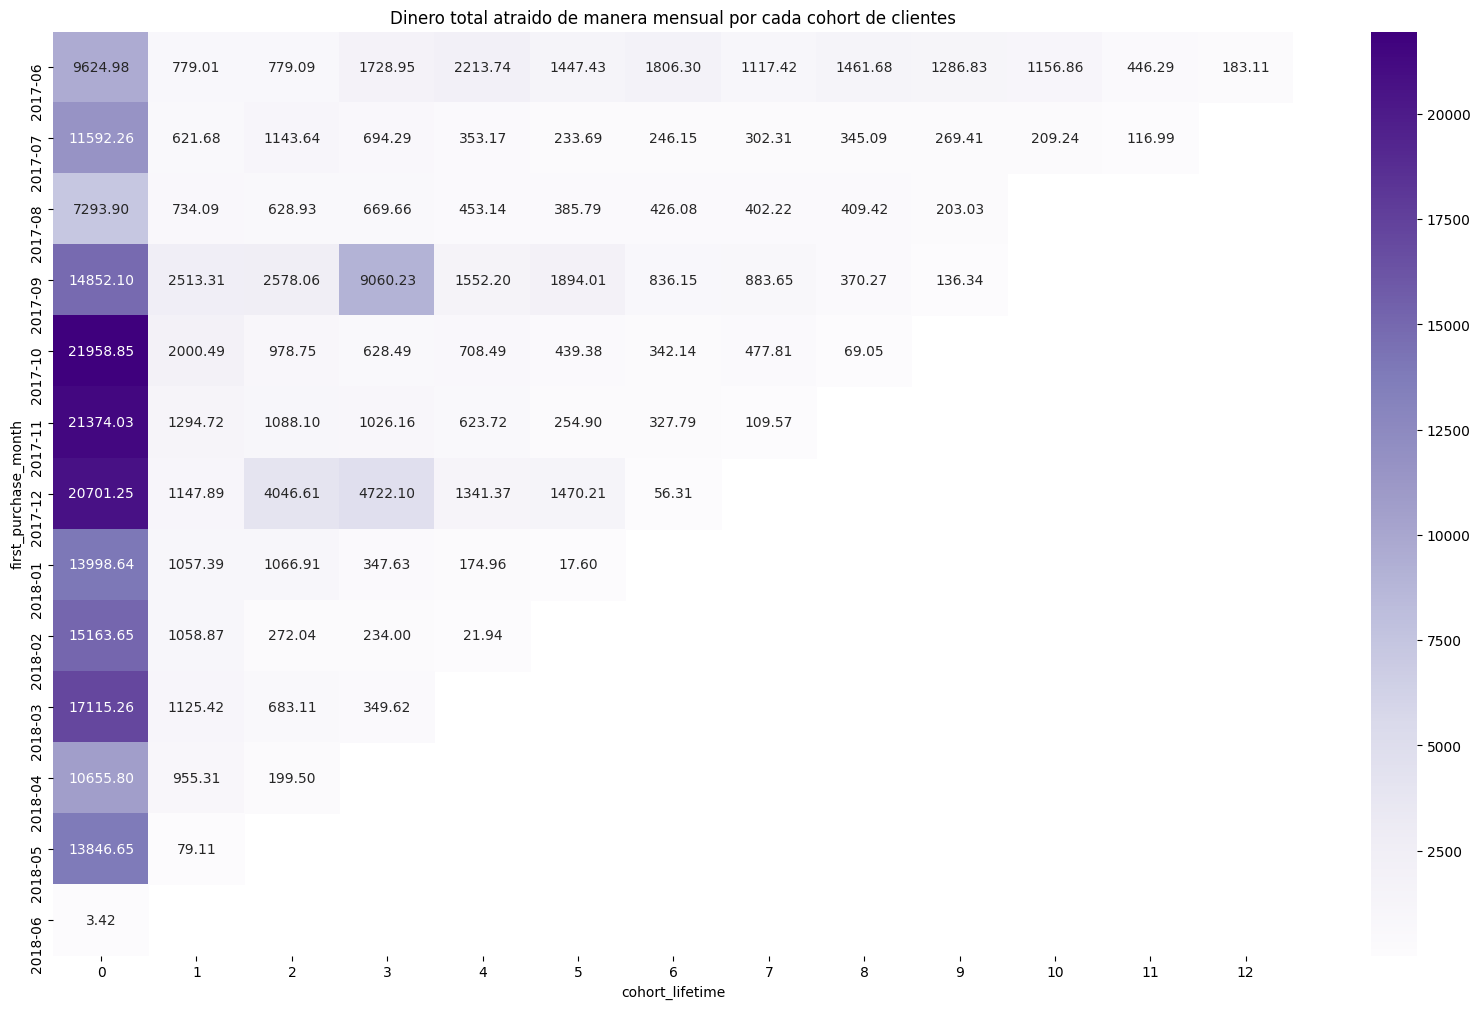

In [56]:
plt.figure(figsize = (20,12))
plt.title('Dinero total atraido de manera mensual por cada cohort de clientes')

sns.heatmap(
    data= ltv,
    annot=True,
    fmt='.2f',
    linecolor='black',
    annot_kws={'size':10},
    cbar=True,
    cmap="Purples"
)

plt.show()


### 2.3.1 ¿Cuanto dinero se gastó?

In [57]:
#Trabajaremos con el DataFrame que contiene los costos de las fuentes de anuncios
costs_df.head()

,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


In [58]:
#Añadimos la primera fecha de registro de cada fuente en un nuevo DataFrame llamado cohorts_costs
first_activity_log = costs_df.groupby('source_id')['dt'].min().reset_index()
first_activity_log.columns = ['source_id', 'first_activity_date']
cohorts_costs = costs_df.merge(first_activity_log, on='source_id')
cohorts_costs.head()

,source_id,dt,costs,first_activity_date
0,1,2017-06-01,75.20,2017-06-01
1,1,2017-06-02,62.25,2017-06-01
2,1,2017-06-03,36.53,2017-06-01
3,1,2017-06-04,55.00,2017-06-01
4,1,2017-06-05,57.08,2017-06-01


In [59]:
#Añadimos una columna con el primer mes de actividad
cohorts_costs['first_activity_month'] = cohorts_costs['first_activity_date'].dt.to_period('M')
cohorts_costs.head()

,source_id,dt,costs,first_activity_date,first_activity_month
0,1,2017-06-01,75.20,2017-06-01,2017-06
1,1,2017-06-02,62.25,2017-06-01,2017-06
2,1,2017-06-03,36.53,2017-06-01,2017-06
3,1,2017-06-04,55.00,2017-06-01,2017-06
4,1,2017-06-05,57.08,2017-06-01,2017-06


In [60]:
#Calculamos el tiempo de vida de cada cohorte
cohorts_costs['cohort_lifetime'] = (cohorts_costs['dt'] - cohorts_costs['first_activity_date'])/np.timedelta64(1, 'M')
cohorts_costs['cohort_lifetime'] = cohorts_costs['cohort_lifetime'].round().astype(int)
cohorts_costs.head()

,source_id,dt,costs,first_activity_date,first_activity_month,cohort_lifetime
0,1,2017-06-01,75.20,2017-06-01,2017-06,0
1,1,2017-06-02,62.25,2017-06-01,2017-06,0
2,1,2017-06-03,36.53,2017-06-01,2017-06,0
3,1,2017-06-04,55.00,2017-06-01,2017-06,0
4,1,2017-06-05,57.08,2017-06-01,2017-06,0


In [61]:
#Creamos la matriz con el total de los gastos mensuales de cada una de las fuentes
cohorts_costs_matrix = cohorts_costs.pivot_table(
    index='source_id',
    columns='cohort_lifetime',
    values='costs',
    aggfunc='sum'
)
cohorts_costs_matrix

cohort_lifetime,0,1,2,3,4,5,6,7,8,9,10,11,12
source_id,,,,,,,,,,,,,
1,710.40,980.90,939.37,1138.70,1972.45,2320.88,2517.61,2176.89,2292.74,2112.88,1479.09,1418.37,772.99
2,1337.96,2363.44,1890.28,2238.60,4194.17,4681.68,5544.23,4337.15,4474.39,4260.56,3351.43,2740.27,1391.88
3,4731.06,7491.77,5894.61,8090.71,13373.19,14660.39,18828.48,14808.72,15360.45,14197.91,9805.76,9169.92,4908.66
4,1935.77,3200.83,3403.21,4311.86,5242.62,6743.50,6983.21,5397.62,6543.76,6546.72,4714.59,3958.70,2091.21
5,1567.32,2674.24,2357.22,2845.58,4930.76,5825.99,6530.37,5552.74,5364.86,4876.30,3679.87,3522.72,2029.13
9,164.79,299.12,255.39,298.18,517.92,635.87,707.50,598.43,574.09,514.41,405.59,363.94,182.26
10,200.52,302.48,236.55,319.78,595.75,681.36,774.96,604.58,599.00,486.88,407.82,395.49,217.32


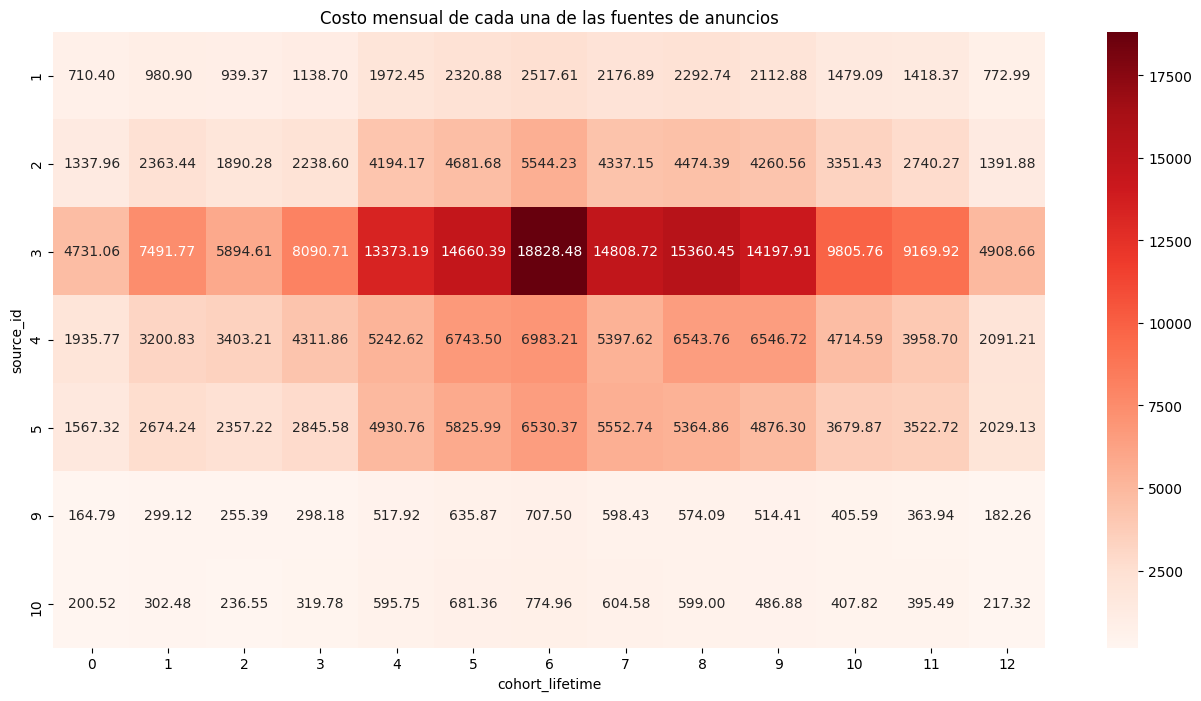

In [62]:
#Heatmap del costo de cada una de las fuentes
plt.figure(figsize = (16, 8))
plt.title('Costo mensual de cada una de las fuentes de anuncios')

sns.heatmap(
    data=cohorts_costs_matrix,
    annot=True,
    fmt='.2f',
    linecolor='black',
    annot_kws={'size':10},
    cbar=True,
    cmap="Reds"
    
)
plt.show()

In [63]:
'''
Podemos observar que dla fuente de adquisicon donde mas se invierte dinero es en la fuente número 3
'''

'\nPodemos observar que dla fuente de adquisicon donde mas se invierte dinero es en la fuente número 3\n'

### 2.3.2 ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?

In [64]:
#Obtenemos el total gastado para cada una de las fuentes
source_costs = cohorts_costs.groupby('source_id')['costs'].sum()
source_costs.name= 'total_cost'
source_costs.head()

source_id
1     20833.27
2     42806.04
3    141321.63
4     61073.60
5     51757.10
Name: total_cost, dtype: float64

In [65]:
source_costs.reset_index().sort_values(by='total_cost', ascending=False)

,source_id,total_cost
2,3,141321.63
3,4,61073.60
4,5,51757.10
1,2,42806.04
0,1,20833.27
6,10,5822.49
5,9,5517.49


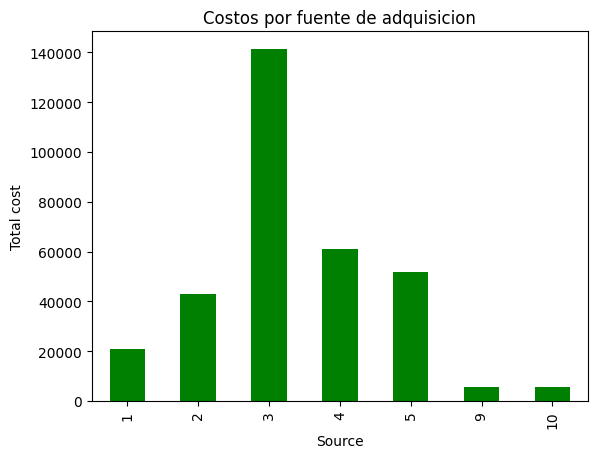

In [66]:
source_costs.plot(
    kind='bar',
    x='source_id',
    y='total_cost',
    xlabel='Source',
    ylabel='Total cost',
    color='green',
    title='Costos por fuente de adquisicion'
)
plt.show()

### 2.3.3  ¿Cuán rentables eran las inversiones? (ROMI)

In [67]:
visits_df.head()

,Device,End Ts,Source Id,Start Ts,Uid,session_time
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,0 days 00:18:00
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,0 days 00:28:00
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,0 days 00:00:00
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,0 days 00:24:00
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,0 days 00:00:00


In [68]:
#Vamos a filtrar el DataFrame visits_df, obteniendo unicamente las visitas en las que se realizó una compra

In [69]:
filtered_visits_df = visits_df.drop('session_time', axis=1)
filtered_visits_df.head()

,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


In [70]:
#Quitamos la hora del día de la visita y dejamos las fechas en formato Datetime
filtered_visits_df['End Ts'] = filtered_visits_df['End Ts'].dt.date
filtered_visits_df['Start Ts'] = filtered_visits_df['Start Ts'].dt.date

filtered_visits_df['End Ts'] = pd.to_datetime(filtered_visits_df['End Ts'])
filtered_visits_df['Start Ts'] = pd.to_datetime(filtered_visits_df['Start Ts'])

filtered_visits_df.head()

,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20,4,2017-12-20,16879256277535980062
1,desktop,2018-02-19,2,2018-02-19,104060357244891740
2,touch,2017-07-01,5,2017-07-01,7459035603376831527
3,desktop,2018-05-20,9,2018-05-20,16174680259334210214
4,desktop,2017-12-27,3,2017-12-27,9969694820036681168


In [71]:
filtered_visits_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  object        
 1   End Ts     359400 non-null  datetime64[ns]
 2   Source Id  359400 non-null  int64         
 3   Start Ts   359400 non-null  datetime64[ns]
 4   Uid        359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB


In [72]:
visits_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype          
---  ------        --------------   -----          
 0   Device        359400 non-null  object         
 1   End Ts        359400 non-null  datetime64[ns] 
 2   Source Id     359400 non-null  int64          
 3   Start Ts      359400 non-null  datetime64[ns] 
 4   Uid           359400 non-null  uint64         
 5   session_time  359400 non-null  timedelta64[ns]
dtypes: datetime64[ns](2), int64(1), object(1), timedelta64[ns](1), uint64(1)
memory usage: 16.5+ MB


In [73]:
orders_df.head()

,Buy Ts,Revenue,Uid
0,2017-06-01,17.00,10329302124590727494
1,2017-06-01,0.55,11627257723692907447
2,2017-06-01,0.37,17903680561304213844
3,2017-06-01,0.55,16109239769442553005
4,2017-06-01,0.37,14200605875248379450


In [74]:
orders_df.duplicated().sum()

1237

In [75]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Buy Ts   50415 non-null  datetime64[ns]
 1   Revenue  50415 non-null  float64       
 2   Uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.5 MB


In [76]:
temp_df = filtered_visits_df.merge(orders_df, on='Uid')
temp_df.head(20)

,Device,End Ts,Source Id,Start Ts,Uid,Buy Ts,Revenue
0,desktop,2018-05-20,9,2018-05-20,16174680259334210214,2018-03-09,2.33
1,desktop,2018-03-09,4,2018-03-09,16174680259334210214,2018-03-09,2.33
2,desktop,2017-09-03,5,2017-09-03,16007536194108375387,2017-09-04,2.44
3,desktop,2017-09-03,5,2017-09-03,16007536194108375387,2017-10-28,1.53
4,desktop,2017-09-03,5,2017-09-03,16007536194108375387,2017-10-28,1.53
5,desktop,2017-10-27,3,2017-10-27,16007536194108375387,2017-09-04,2.44
6,desktop,2017-10-27,3,2017-10-27,16007536194108375387,2017-10-28,1.53
7,desktop,2017-10-27,3,2017-10-27,16007536194108375387,2017-10-28,1.53
8,desktop,2017-09-04,4,2017-09-04,16007536194108375387,2017-09-04,2.44
9,desktop,2017-09-04,4,2017-09-04,16007536194108375387,2017-10-28,1.53


In [77]:
temp_df.drop_duplicates(inplace=True)

In [78]:
temp_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 582012 entries, 0 to 761806
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     582012 non-null  object        
 1   End Ts     582012 non-null  datetime64[ns]
 2   Source Id  582012 non-null  int64         
 3   Start Ts   582012 non-null  datetime64[ns]
 4   Uid        582012 non-null  uint64        
 5   Buy Ts     582012 non-null  datetime64[ns]
 6   Revenue    582012 non-null  float64       
dtypes: datetime64[ns](3), float64(1), int64(1), object(1), uint64(1)
memory usage: 35.5+ MB


In [79]:
complete_df = temp_df[(temp_df['Buy Ts'] >= temp_df['Start Ts']) & ((temp_df['Buy Ts'] <= temp_df['End Ts']))]
#complete_df = temp_df[temp_df['Buy Ts'].between(temp_df['Start Ts'], temp_df['End Ts'])]
complete_df.head(20)

,Device,End Ts,Source Id,Start Ts,Uid,Buy Ts,Revenue
1,desktop,2018-03-09,4,2018-03-09,16174680259334210214,2018-03-09,2.33
8,desktop,2017-09-04,4,2017-09-04,16007536194108375387,2017-09-04,2.44
12,desktop,2017-10-28,3,2017-10-27,16007536194108375387,2017-10-28,1.53
29,desktop,2017-09-04,3,2017-09-04,16007536194108375387,2017-09-04,2.44
105,desktop,2017-12-05,1,2017-12-05,8056418121947262981,2017-12-05,3.67
258,desktop,2018-03-06,2,2018-03-06,8056418121947262981,2018-03-06,3.05
287,desktop,2018-03-06,1,2018-03-06,8056418121947262981,2018-03-06,3.05
346,desktop,2018-03-08,1,2018-03-08,8056418121947262981,2018-03-08,4.89
355,desktop,2017-06-26,1,2017-06-26,8056418121947262981,2017-06-26,3.67
356,desktop,2017-06-26,1,2017-06-26,8056418121947262981,2017-06-26,12.22


In [80]:
complete_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 46927 entries, 1 to 761806
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Device     46927 non-null  object        
 1   End Ts     46927 non-null  datetime64[ns]
 2   Source Id  46927 non-null  int64         
 3   Start Ts   46927 non-null  datetime64[ns]
 4   Uid        46927 non-null  uint64        
 5   Buy Ts     46927 non-null  datetime64[ns]
 6   Revenue    46927 non-null  float64       
dtypes: datetime64[ns](3), float64(1), int64(1), object(1), uint64(1)
memory usage: 2.9+ MB


In [81]:
complete_df.duplicated().sum()

0

In [82]:
costs_df.head()

,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08
